# No-look-ahead backtest: trade only deadlines that were public before the entry

**The problem.** Every earlier notebook takes the deadline D from `suspension.csv`, a record compiled after the fact.
The trade buys at the close of D−6, so it silently assumes you knew on D−6 that a forced short-covering deadline was
coming on D. If the event was announced on D−3, that trade could not have been placed.

**The fix.** Build the events from what was public at the time. For ex-dividend / ex-rights events the deadline is
D = ex-date − 4 trading days, and the ex-date is public from the minute the company posts it on MOPS (t108sb27, pulled by
`collect_mops_exdiv.py` with the date and time of each posting). A trade is taken only if the announcement was posted
**before the close of the entry day**: on an earlier date, or on the entry date before 13:25 when the closing auction
starts.

**AGM deadlines (股東常會)** are the largest event category, and their ex-date logic does not apply. Their posting
times come from `data/mops_agm.csv` (`collect_mops_agm.py`: the board's "召開股東常會" material-information posting whose
book-closure date implies the same D). An AGM event is traded only if that posting was found and was public by the
entry close. AGM events not looked up or not matched are dropped, never assumed known.

**Same trade as the purple line in `backtest_hedged.ipynb`:** Q5 = days-to-cover on D−17 ≥ 0.167, 20-day turnover ≥
NT$20m, buy at the close of **D−6**, flip to short at the close of D, cover at the close of **D+5**, beta-hedged with
TAIEX futures (Dimson beta on the 250 days ending D−17, Blume-shrunk), 20bp per leg + β×2bp hedge, fixed notional per
trade.

**Look-ahead checklist**

| Input | Known by the entry (close of D−6)? |
|---|---|
| That a deadline exists, and its date D | **Now yes:** MOPS posting time is checked against the entry |
| D = ex-date − 4 trading days | Yes: the exchange holiday calendar is published a year ahead (typhoon closures are the exception) |
| Days-to-cover and turnover on D−17 | Yes: published the evening of D−17 |
| Beta (250 days ending D−17) | Yes |
| Threshold 0.167, D−6, 5 days | Fixed on 2018–2023 data, which **includes AGM events**; fair for the out-of-sample period only |

**Not fixed here.** Stock returns still stand in for single-stock futures. MOPS may overwrite a posting date when a
company files a correction. That would make an event look announced *later* than it was, which drops trades
rather than adding look-ahead.

## 1. Data
**What this does.** Same TWSE panel, signal inputs and TAIEX hedge return as `backtest_hedged.ipynb`, plus the MOPS
announcements.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
K, H = 6, 5                  # purple line from backtest_hedged.ipynb: long from the close of D-6 to D, short from the close of D to D+5
THR = 0.167                  # frozen: in-sample 80th pct of days-to-cover on D-17 (insample.ipynb)
SIG_LAG, MIN_VAL20, COST_LEG_BPS = 17, 2e7, 20
K_LABEL, H_LABEL = 12, 20    # in/out-of-sample split exactly as backtest_hedged.ipynb
BETA_WIN, BETA_MIN, DIMSON_LAGS = 250, 60, 2
HEDGE_BPS, RF = 2, 0.015
EX_TO_D = 4                  # D = ex-date - 4 trading days
CLOSE_AUCTION = "13:25:00"   # an announcement must be posted before this on the entry day

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)
R = wide(px, "ret")
SB = wide(mg, "short_bal")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T = len(cal); Rv = R.values
CUT = int(T * 2 / 3)
taiex = idx.taiex_tr.pct_change(fill_method=None).fillna(0).values
HEDGE_R = taiex - RF / 252

mops = pd.read_csv(DATA / "mops_exdiv.csv", dtype={"stock_id": str, "announce_time": str},
                   parse_dates=["ex_rights_date", "ex_div_date", "announce_date"])
print(f"MOPS announcements: {len(mops):,} rows, {mops.stock_id.nunique():,} companies, "
      f"posted {mops.announce_date.min().date()} -> {mops.announce_date.max().date()}")

MOPS announcements: 15,569 rows, 1,909 companies, posted 2017-01-06 -> 2026-10-07


## 2. Events from announcements
**What this does.** Each MOPS row becomes an event: ex-date = the earlier of the ex-rights and ex-dividend dates,
D = ex-date − 4 trading days. Rows for the same stock whose D falls within 10 trading days of each other are one
event (e.g. a cash dividend and a stock dividend posted separately); it keeps the **earliest posting**, since the
deadline was public from then.

It then checks this D against `suspension.csv`: the share of announcement-based events whose D matches a recorded
ex-dividend / ex-rights suspension for the same stock.

In [2]:
m = mops[mops.stock_id.isin(stocks)].copy()
m["ex"] = m[["ex_rights_date", "ex_div_date"]].min(axis=1)
m = m.dropna(subset=["ex", "announce_date"])
ex_i = cal.searchsorted(m.ex.values)
m = m[(ex_i < T) & (ex_i >= EX_TO_D)]
m["D"] = cal.searchsorted(m.ex.values) - EX_TO_D
m["announce_time"] = m.announce_time.fillna("23:59:59").str.strip()
m = m.sort_values(["stock_id", "D", "announce_date", "announce_time"])
m["grp"] = (m.groupby("stock_id").D.diff().fillna(99) >= 10).cumsum()
ev = m.groupby("grp").agg(stock_id=("stock_id", "first"), D=("D", "first"), ex=("ex", "first"),
                          announce_date=("announce_date", "first"), announce_time=("announce_time", "first"),
                          rows=("D", "size")).reset_index(drop=True)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
print(f"announcement-based events: {len(ev):,} ({(ev.rows > 1).sum():,} merged from more than one row)")

sus = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
EXDIV_REASONS = ["除息", "除權息", "除權", "除權、息", "現增除權", "現金增資"]
sus["D"] = cal.searchsorted(sus.date.values)
sx = sus[sus.reason.isin(EXDIV_REASONS)]
key = lambda df, sh=0: set(zip(df.stock_id, df.D + sh))
exact, near = key(sx), key(sx) | key(sx, 1) | key(sx, -1)
in_range = (ev.D >= cal.searchsorted(sx.date.min())) & (ev.D <= cal.searchsorted(sx.date.max()))
hit = np.array([(s, d) in exact for s, d in zip(ev.stock_id, ev.D)])
hit1 = np.array([(s, d) in near for s, d in zip(ev.stock_id, ev.D)])
print(f"D matches a recorded ex-div suspension: exactly {hit[in_range].mean():.0%}, within 1 day {hit1[in_range].mean():.0%}")
print("(no match usually means the stock had no margin shorts to suspend, which the Q5 filter removes anyway)")

announcement-based events: 7,905 (26 merged from more than one row)
D matches a recorded ex-div suspension: exactly 90%, within 1 day 92%
(no match usually means the stock had no margin shorts to suspend, which the Q5 filter removes anyway)


## 3. Signal, the announcement filter, and three event sets
**What this does.** Applies the frozen Q5 threshold and liquidity filter on D−17, then compares three sets on the
same trade:

* **A: `suspension.csv`, all reasons**, the purple line from `backtest_hedged.ipynb` (assumes every deadline,
  AGMs included, was known at D−6).
* **B: announcement-based, timing ignored**: ex-dividend / ex-rights events from MOPS, entered even if the posting came
  after the entry.
* **C: announcement-based ex-div, posted before the entry close** (no look-ahead on the event).
* **D: C plus AGM events whose posting was public before the entry close** (the headline when the AGM lookup covers
  every AGM event in A).

The B → C gap is the cost of the timing filter. The A → B gap comes mostly from dropping the AGM events.

AGM events in A: 742; looked up on MOPS so far: 742; announcement found: 708; public by the close of D−6: 704
count    708.0
mean      14.9
std        7.1
min        5.0
1%         6.0
5%         7.0
10%        7.0
50%       14.0
max       43.0
events traded (Q5, liquid):
               A suspension, all  B MOPS, timing ignored  C MOPS, known at entry  D = C + AGMs known at entry
period                                                                                                       
in-sample                   1059                     428                     365                          943
out-of-sample                208                      83                      70                          196

A by reason: {'股東常會': 742, '除息': 408, '現金增資': 45, '除權息': 42, '減資': 15, '除權': 10, '變更面額': 2, '股份轉換': 1, '其他': 1, '合併': 1}

B events announced too late to enter at the close of D−6: 76 of 511 (14.9%)


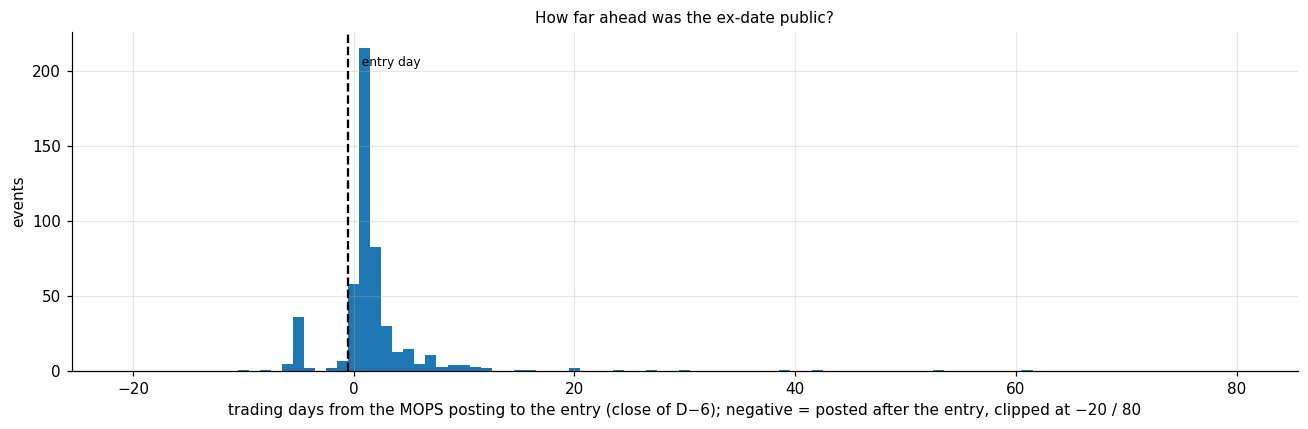

count    511.0
mean       1.9
std        5.7
min      -10.0
1%        -6.0
5%        -5.0
10%       -1.0
50%        1.0
max       61.0


In [3]:
def signal(df):
    df = df[(df.D >= SIG_LAG + 1) & (df.D + H + 1 < T)].copy()
    df["j"] = df.stock_id.map(col)
    s_ = df.D.values - SIG_LAG
    df["sb"] = SB.values[s_, df.j.values]
    df["dtc"] = df.sb / ADV.values[s_, df.j.values]
    df["val20"] = VAL20.values[s_, df.j.values]
    df["Ddate"] = cal[df.D.values]
    df["period"] = np.select([df.D + H_LABEL < CUT, df.D - K_LABEL >= CUT], ["in-sample", "out-of-sample"], "boundary")
    return df[(df.sb > 0) & (df.dtc >= THR) & (df.val20 >= MIN_VAL20) & (df.period != "boundary")].reset_index(drop=True)

# A: suspension.csv, every reason, as in backtest_hedged.ipynb
sa = sus[sus.stock_id.isin(stocks)].copy()
sa = sa[(sa.D >= SIG_LAG + 1) & (sa.D + H + 1 < T)].sort_values(["stock_id", "D"])
sa = sa[sa.groupby("stock_id").D.diff().fillna(99) >= 10]
A = signal(sa[["stock_id", "D", "reason"]])

# B and C: from MOPS
B = signal(ev)
entry = cal[B.D.values - K]
B["entry_date"] = entry
B["lead_days"] = np.array([cal.searchsorted(e) for e in entry]) - cal.searchsorted(B.announce_date.values)
B["known"] = (B.announce_date < B.entry_date) | ((B.announce_date == B.entry_date) & (B.announce_time < CLOSE_AUCTION))
C = B[B.known].reset_index(drop=True)

# AGM events: posting times from data/mops_agm.csv (collect_mops_agm.py), when available.
# lead = trading days from the first close after the posting to D; the D-K entry is feasible only if lead >= K.
AG = A[A.reason == "股東常會"].copy()
agm_path = DATA / "mops_agm.csv"
if agm_path.exists():
    agm = pd.read_csv(agm_path, dtype={"stock_id": str}, parse_dates=["D"])
    agm["D"] = cal.searchsorted(agm.D.values)
    agm = agm.drop_duplicates(["stock_id", "D"])
    AG = AG.merge(agm[["stock_id", "D", "matched", "lead"]], on=["stock_id", "D"], how="left")
else:
    AG["matched"], AG["lead"] = np.nan, np.nan
AG["looked_up"] = AG.matched.notna()
AG["known"] = AG.matched.eq(True) & (AG.lead >= K)
COLS = ["stock_id", "D", "j", "Ddate", "period"]
DD = pd.concat([C[COLS], AG.loc[AG.known, COLS]], ignore_index=True)
print(f"AGM events in A: {len(AG)}; looked up on MOPS so far: {AG.looked_up.sum()}; announcement found: {AG.matched.eq(True).sum()}; "
      f"public by the close of D−{K}: {AG.known.sum()}")
if AG.looked_up.any():
    print(AG.loc[AG.matched.eq(True), "lead"].describe(percentiles=[.01, .05, .1, .5]).round(1).to_string())

print("events traded (Q5, liquid):")
print(pd.DataFrame({nm: df.groupby("period").size() for nm, df in [("A suspension, all", A), ("B MOPS, timing ignored", B),
                                                                    ("C MOPS, known at entry", C), ("D = C + AGMs known at entry", DD)]}).to_string())
print("\nA by reason:", A.reason.value_counts().to_dict())
print(f"\nB events announced too late to enter at the close of D−{K}: {(~B.known).sum()} of {len(B)} ({(~B.known).mean():.1%})")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(B.lead_days.clip(-20, 80), bins=np.arange(-20.5, 81.5, 1), color="C0")
ax.axvline(-0.5, color="k", ls="--"); ax.text(0, ax.get_ylim()[1] * .9, "  entry day", fontsize=8)
ax.set_xlabel(f"trading days from the MOPS posting to the entry (close of D−{K}); negative = posted after the entry, clipped at −20 / 80")
ax.set_ylabel("events"); ax.set_title("How far ahead was the ex-date public?", fontsize=10)
plt.tight_layout(); plt.show()
print(B.lead_days.describe(percentiles=[.01, .05, .1, .5]).round(1).to_string())

## 4. Beta and the P&L engine
**What this does.** Same as `backtest_hedged.ipynb`: Dimson beta (lags 0–2) on the 250 days ending D−17, Blume-shrunk,
β = 1 with fewer than 60 usable days. Each trade holds +1 stock / −β TAIEX futures on D−5…D, then −1 stock / +β futures
on D+1…D+5. Costs 20bp + β×2bp on D and on D+5. Fixed notional per trade.

In [4]:
M_LAGS = np.column_stack([np.r_[np.full(k, np.nan), taiex[:T - k]] for k in range(DIMSON_LAGS + 1)])

def beta(j, end):
    rows = slice(max(0, end - BETA_WIN + 1), end + 1)
    y, X = Rv[rows, j], M_LAGS[rows]
    ok = np.isfinite(y) & np.isfinite(X).all(1) & (np.abs(y) < 0.095)
    if ok.sum() < BETA_MIN:
        return 1.0
    b = np.linalg.lstsq(np.column_stack([np.ones(ok.sum()), X[ok]]), y[ok], rcond=None)[0][1:].sum()
    return 0.67 * b + 0.33

OFF = np.arange(-K + 1, H + 1)
SIGN = np.where(OFF <= 0, 1.0, -1.0)
cost, hcost = COST_LEG_BPS / 1e4, HEDGE_BPS / 1e4

def book(df, hedged=True):
    b = np.array([beta(j, d - SIG_LAG) for j, d in zip(df.j.values, df.D.values)]) * hedged
    days = df.D.values[:, None] + OFF[None, :]
    rs = np.nan_to_num(Rv[days, df.j.values[:, None]])
    pnl = SIGN[None, :] * (rs - b[:, None] * HEDGE_R[days])
    leg_cost = cost + np.abs(b) * hcost
    pnl[:, OFF == 0] -= leg_cost[:, None]; pnl[:, OFF == H] -= leg_cost[:, None]
    s = np.zeros(T); c = np.zeros(T)
    np.add.at(s, days.ravel(), pnl.ravel()); np.add.at(c, days.ravel(), 1)
    return {"fixed": pd.Series(s, cal), "npos": pd.Series(c, cal), "net": pnl.sum(1),
            "long": pnl[:, OFF <= 0].sum(1), "short": pnl[:, OFF >= 1].sum(1), "beta": b}

sharpe = lambda d: d.mean() / d.std() * np.sqrt(252) if d.std() > 0 else np.nan
SETS = {"A suspension.csv, all reasons (look-ahead)": A, "B MOPS ex-div, timing ignored": B, "C MOPS ex-div, known at entry": C,
        "D ex-div + AGM, known at entry": DD}
RUNS = {nm: book(df) for nm, df in SETS.items()}
C_UNH = book(C, hedged=False)

## 5. P&L
**What this does.** Cumulative fixed-notional P&L for the three sets, with the out-of-sample period shaded. Then
set C split into legs, and set C hedged vs unhedged.

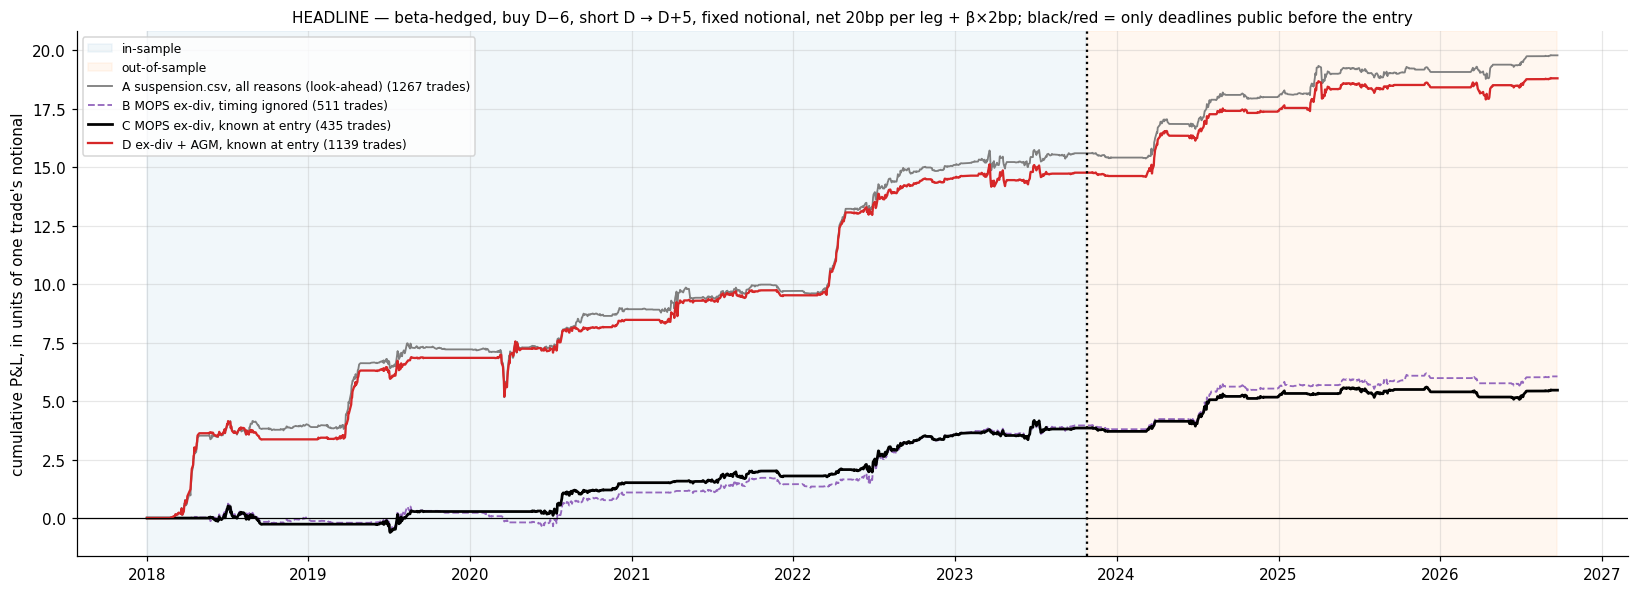

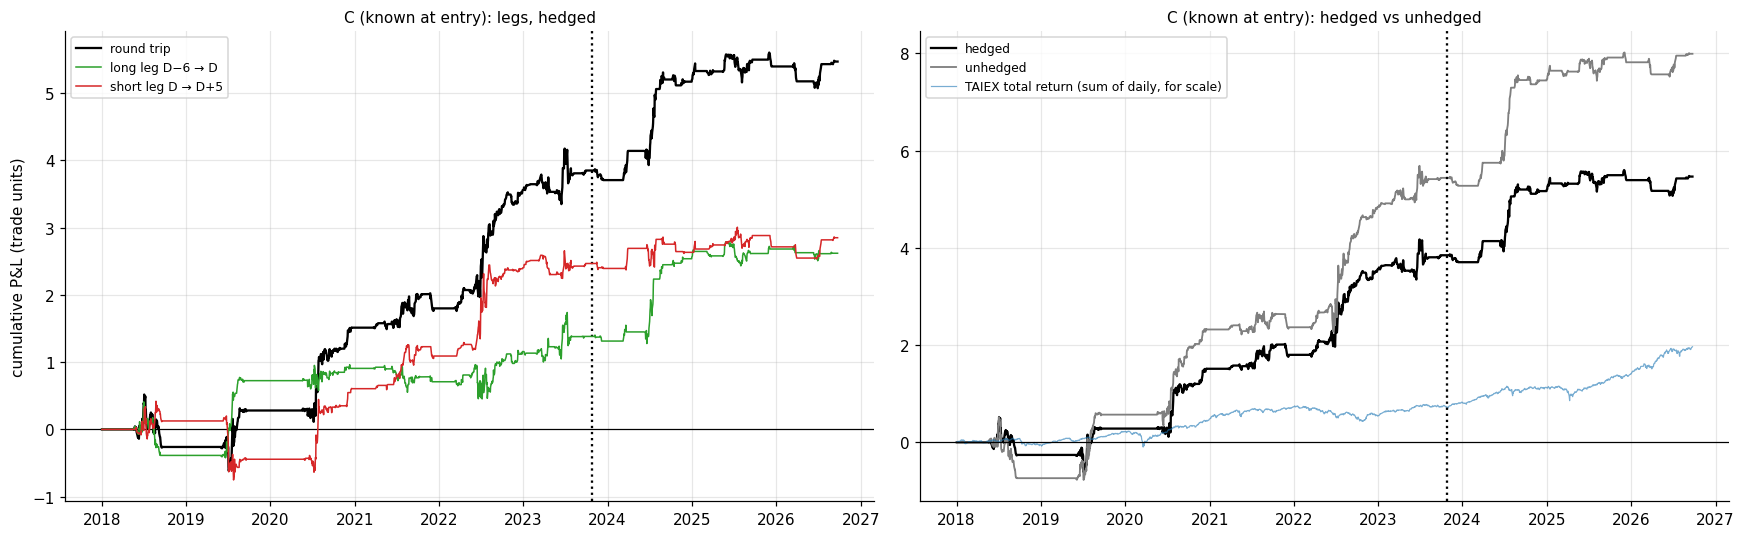

In [5]:
is_day = np.arange(T) < CUT
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.axvspan(cal[0], cal[CUT - 1], color="C0", alpha=.06, label="in-sample")
ax.axvspan(cal[CUT], cal[-1], color="C1", alpha=.06, label="out-of-sample")
for (nm, r), c, lw, ls in zip(RUNS.items(), ["C7", "C4", "k", "C3"], [1.2, 1.2, 1.8, 1.5], ["-", "--", "-", "-"]):
    ax.plot(cal, r["fixed"].cumsum(), color=c, lw=lw, ls=ls, label=f"{nm} ({len(SETS[nm])} trades)")
ax.axvline(cal[CUT], color="k", ls=":"); ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("cumulative P&L, in units of one trade's notional")
ax.set_title(f"HEADLINE — beta-hedged, buy D−{K}, short D → D+{H}, fixed notional, net {COST_LEG_BPS}bp per leg + β×{HEDGE_BPS}bp; "
             "black/red = only deadlines public before the entry", fontsize=10)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

rc = RUNS["C MOPS ex-div, known at entry"]
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
a = ax[0]
a.plot(cal, rc["fixed"].cumsum(), color="k", lw=1.5, label="round trip")
long_d = pd.Series(0.0, cal); short_d = pd.Series(0.0, cal)
a.axvline(cal[CUT], color="k", ls=":"); a.axhline(0, color="k", lw=.8)
days = C.D.values[:, None] + OFF[None, :]
b = rc["beta"]
pnl = SIGN[None, :] * (np.nan_to_num(Rv[days, C.j.values[:, None]]) - b[:, None] * HEDGE_R[days])
lc = cost + np.abs(b) * hcost
pnl[:, OFF == 0] -= lc[:, None]; pnl[:, OFF == H] -= lc[:, None]
np.add.at(long_d.values, days[:, OFF <= 0].ravel(), pnl[:, OFF <= 0].ravel())
np.add.at(short_d.values, days[:, OFF >= 1].ravel(), pnl[:, OFF >= 1].ravel())
a.plot(cal, long_d.cumsum(), color="C2", lw=1, label=f"long leg D−{K} → D")
a.plot(cal, short_d.cumsum(), color="C3", lw=1, label=f"short leg D → D+{H}")
a.set_title("C (known at entry): legs, hedged", fontsize=10); a.legend(fontsize=8, loc="upper left"); a.set_ylabel("cumulative P&L (trade units)")
a = ax[1]
a.plot(cal, rc["fixed"].cumsum(), color="k", lw=1.5, label="hedged")
a.plot(cal, C_UNH["fixed"].cumsum(), color="C7", lw=1.2, label="unhedged")
a.plot(cal, np.cumsum(taiex), color="C0", lw=.8, alpha=.6, label="TAIEX total return (sum of daily, for scale)")
a.axvline(cal[CUT], color="k", ls=":"); a.axhline(0, color="k", lw=.8)
a.set_title("C (known at entry): hedged vs unhedged", fontsize=10); a.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

## 6. Statistics
**What this does.** For each set and period: fixed-notional Sharpe, total P&L and max drawdown in trade units, trades,
mean net bp per trade and per leg, hit rate, t-stat across deadline dates, and correlation with TAIEX. Then set C by
year.

In [6]:
rows = {}
for nm, r in list(RUNS.items()) + [("C unhedged", C_UNH)]:
    df = SETS.get(nm, C)
    for per, dm in [("in-sample", is_day), ("out-of-sample", ~is_day)]:
        tm = (df.period == per).values
        fx = r["fixed"][dm]; eq = fx.cumsum(); op = dm & (r["npos"].values > 0)
        pdm = pd.Series(r["net"][tm]).groupby(df.Ddate.values[tm]).mean()
        rows[(nm[:1] if nm != "C unhedged" else "C unhedged", per)] = {
            "fixed-notional Sharpe": sharpe(fx), "total P&L (trade units)": fx.sum(), "max drawdown (trade units)": (eq - eq.cummax()).min(),
            "trades": tm.sum(), "deadline dates": len(pdm), "mean net / trade bp": r["net"][tm].mean() * 1e4,
            "long leg / trade bp": r["long"][tm].mean() * 1e4, "short leg / trade bp": r["short"][tm].mean() * 1e4,
            "hit rate": (r["net"][tm] > 0).mean(), "t (per date)": pdm.mean() / pdm.std() * np.sqrt(len(pdm)),
            "corr with TAIEX": np.corrcoef(r["fixed"].values[op], taiex[op])[0, 1]}
print(pd.DataFrame(rows).round(3).to_string())

yr = []
for y, g in C.groupby(C.Ddate.dt.year):
    dm = cal.year == y; tm = (C.Ddate.dt.year == y).values
    yr.append({"year": y, "trades": len(g), "mean net bp": rc["net"][tm].mean() * 1e4, "long bp": rc["long"][tm].mean() * 1e4,
               "short bp": rc["short"][tm].mean() * 1e4, "hit": (rc["net"][tm] > 0).mean(), "Sharpe": sharpe(rc["fixed"][dm]),
               "period": "/".join(sorted(g.period.unique()))})
print("\nC (known at entry) by year:")
print(pd.DataFrame(yr).set_index("year").round(2).to_string())

                                   A                       B                       C                       D               C unhedged              
                           in-sample out-of-sample in-sample out-of-sample in-sample out-of-sample in-sample out-of-sample  in-sample out-of-sample
fixed-notional Sharpe          2.006         1.622     0.892         1.321     0.964         1.140     2.065         1.533      1.182         1.840
total P&L (trade units)       15.593         4.185     3.958         2.097     3.847         1.619    14.762         4.033      5.440         2.553
max drawdown (trade units)    -2.306        -0.744    -1.149        -0.530    -1.133        -0.530    -1.793        -0.782     -1.292        -0.496
trades                      1059.000       208.000   428.000        83.000   365.000        70.000   943.000       196.000    365.000        70.000
deadline dates               361.000       103.000   267.000        68.000   227.000        58.000   307.000    

**Interpretation.** *(AGM lookup complete: all 742 AGM events looked up, 708 postings found.)*
- **Ex-div deadlines are announced late.** The median ex-div posting comes just **1 trading day** before the D−6 entry,
  and **15% (76 of 511) come after it**. Those trades were impossible. A D−12 entry would lose most ex-div events.
- **Dropping them barely changes the ex-div result** (B → C): Sharpe 0.89 → 0.96 in-sample, 1.32 → 1.14 out-of-sample,
  +231bp per trade out-of-sample on 70 trades (t = 1.4). The look-ahead was real, but it was not what made the
  strategy look good.
- **AGM deadlines are announced early.** Of the 708 AGM postings found, 704 were public by the D−6 close (median
  lead 14 trading days). The AGM events are almost all tradable; until now they were missing only because the posting
  data didn't exist.
- **The gap between A and C is mostly sample, not look-ahead.** Ex-div-only events earn about 105bp per trade in-sample,
  compared with 147bp for all events. The AGM events are the stronger half of the strategy.
- **Set D, the headline, nearly recovers A.** Sharpe 2.07 in-sample (A 2.01) and 1.53 out-of-sample (A 1.62), on 943 /
  196 trades (A 1059 / 208), +157bp / +206bp per trade. Removing the look-ahead on the event costs little once the AGM
  postings are in.
- **Hedged vs unhedged on C:** hedging lowers out-of-sample Sharpe (1.84 → 1.14). 2024 was a strong up year, so the
  hedge cost money, while in-sample it was roughly a wash (1.18 → 0.96). It still takes out the market risk:
  correlation with TAIEX is about 0.